In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Audio, display
from pynwb import NWBHDF5IO
from collections import Counter

import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, IntSlider, FloatSlider, Dropdown, Checkbox

from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from phonetic_dictionary import PhoneticDictionary
from hybrid_phoneme_models import HybridPhonemeModels
from unified_phoneme_pipeline import UnifiedPhonemePipeline
from markov_phoneme_model import MarkovPhonemeModel
from markov_children import  GMMHMMModel, HSMMModel

In [2]:
# Define paths
path_bids = './SingleWordProductionDutch-iBIDS'
path_output = './features'
path_results = './results'

# Create directories if they don't exist
os.makedirs(path_output, exist_ok=True)
os.makedirs(path_results, exist_ok=True)

In [3]:
use_augmentation=True
feature_extraction_method= 'high_gamma'  # 'multi_band'

# Try to load existing pipeline, otherwise create new one
try:
    # Try loading existing pipeline
    pipeline_hg = UnifiedPhonemePipeline.load_saved(path_results, method=feature_extraction_method)
    print(f"Loaded existing {feature_extraction_method} pipeline")
    
except (FileNotFoundError, AttributeError, TypeError) as e:
    # No existing pipeline found, create new one
    print(f"No existing {feature_extraction_method} pipeline found. Creating new one...")
    
    pipeline_hg = UnifiedPhonemePipeline(
        path_bids=path_bids,
        path_output=path_output,
        path_results=path_results,
        feature_extraction_method=feature_extraction_method,
        unknown_keep_ratio=0.1,
        debug_mode=False
    )
    
    # Run all steps
    print("Running pipeline steps...")
    pipeline_hg.step1_initialize_decoder()
    pipeline_hg.step2_stratify_participants()    
    pipeline_hg.step3_create_split()
    pipeline_hg.step4_initialize_detector()    
    pipeline_hg.step5_accumulate_data()
    pipeline_hg.step6_resolve_unknowns()
    pipeline_hg.step7_filter_unknowns()
    
    # Save the pipeline
    pipeline_hg.save()
    print(f"Created and saved new {feature_extraction_method} pipeline")

UnifiedPhonemePipeline: Initialized with DEBUG_MODE=False
Pipeline initialized
Loaded high_gamma pipeline
Loaded pipeline_high_gamma.pkl
Loaded existing high_gamma pipeline


In [4]:
use_augmentation=True
feature_extraction_method= 'multi_band'  # 'multi_band'

# Try to load existing pipeline, otherwise create new one
try:
    # Try loading existing pipeline
    pipeline_mb = UnifiedPhonemePipeline.load_saved(path_results, method=feature_extraction_method)
    print(f"Loaded existing {feature_extraction_method} pipeline")
    
except (FileNotFoundError, AttributeError, TypeError) as e:
    # No existing pipeline found, create new one
    print(f"No existing {feature_extraction_method} pipeline found. Creating new one...")
    
    pipeline_mb = UnifiedPhonemePipeline(
        path_bids=path_bids,
        path_output=path_output,
        path_results=path_results,
        feature_extraction_method=feature_extraction_method,
        unknown_keep_ratio=0.1,
        debug_mode=False
    )
    
    # Run all steps
    print("Running pipeline steps...")
    pipeline_mb.step1_initialize_decoder()
    pipeline_mb.step2_stratify_participants()    
    pipeline_mb.step3_create_split()
    pipeline_mb.step4_initialize_detector()    
    pipeline_mb.step5_accumulate_data()
    pipeline_mb.step6_resolve_unknowns()
    pipeline_mb.step7_filter_unknowns()
    
    # Save the pipeline
    pipeline_mb.save()
    print(f"Created and saved new {feature_extraction_method} pipeline")

UnifiedPhonemePipeline: Initialized with DEBUG_MODE=False
Pipeline initialized
Loaded multi_band pipeline
Loaded pipeline_multi_band.pkl
Loaded existing multi_band pipeline


In [5]:
# train_data = pipeline.step_outputs['train_filtered']
# test_data = pipeline.step_outputs['test_raw']
# # 1. Get FILTERED training labels (what you actually train with):
# train_labels = pipeline.train_filtered['phoneme_labels']

# # 2. Get RAW training labels (before filtering):
# raw_train_labels = pipeline.train['phoneme_labels']

# # 3. Get test labels:
# test_labels = pipeline.test['phoneme_labels']

# # 4. Using the getter method:
# train_data = pipeline.get_training_data(filtered=True)
# train_labels = train_data['phoneme_labels']

# # 5. From step_outputs:
# train_labels = pipeline.step_outputs['train_filtered']['phoneme_labels']

# # To check what you have:
# print(f"Number of labels: {len(train_labels)}")
# print(f"First 10 labels: {train_labels[:10]}")
# print(f"Label distribution: {Counter(train_labels).most_common(10)}")

NameError: name 'pipeline' is not defined

In [10]:
from phonetic_dictionary import PhoneticDictionary
phonetic_dict = PhoneticDictionary()

PhoneticDictionary: Initialized with DEBUG_MODE=False


In [17]:
# Get FILTERED data (this is what you feed to the Markov model):
hg_train_data = pipeline_hg.get_training_data(filtered=True)  # or pipeline.train_filtered

# Extract all components:
hg_filtered_features = hg_train_data['features']
hg_filtered_labels = hg_train_data['phoneme_labels']
hg_filtered_words = hg_train_data['phoneme_words']
hg_filtered_participants = hg_train_data['phoneme_participant_ids']

hg_test_features = pipeline_hg.test['features']
hg_test_labels = pipeline_hg.test['phoneme_labels']

# Get FILTERED data (this is what you feed to the Markov model):
mb_train_data = pipeline_mb.get_training_data(filtered=True)  # or pipeline.train_filtered

# Extract all components:
mb_filtered_features = mb_train_data['features']
mb_filtered_labels = mb_train_data['phoneme_labels']
mb_filtered_words = mb_train_data['phoneme_words']
mb_filtered_participants = mb_train_data['phoneme_participant_ids']

mb_test_features = pipeline_mb.test['features']
mb_test_labels = pipeline_mb.test['phoneme_labels']

In [12]:
# Initiate:
markov_model = MarkovPhonemeModel(
    phonetic_dict=phonetic_dict,
    order=2,
    output_dir=os.path.join(path_results, 'markov_model'),
    debug_mode=True
)

gmm_model = GMMHMMModel(
    phonetic_dict=phonetic_dict,
    order=2,
    n_mix=5,
    output_dir=os.path.join(path_results, 'gmm_hmm'),
    debug_mode=True
)

hsmm_model = HSMMModel(
        phonetic_dict=phonetic_dict,
        order=2,
        max_duration=50,
        output_dir=os.path.join(path_results, 'hsmm'),
        debug_mode=False
    )

MarkovPhonemeModel: Initialized with DEBUG_MODE=True
MarkovPhonemeModel: Initialized MarkovPhonemeModel with order=2
MarkovPhonemeModel: Initialized with DEBUG_MODE=True
MarkovPhonemeModel: Initialized MarkovPhonemeModel with order=2
MarkovPhonemeModel: Initialized GMM-HMM with 5 mixtures per state
MarkovPhonemeModel: Initialized with DEBUG_MODE=False
MarkovPhonemeModel: Initialized MarkovPhonemeModel with order=2
MarkovPhonemeModel: Initialized HSMM with max duration 50


In [18]:
results = {}
hg_train_parameters = {
    'features': hg_filtered_features,
    'phoneme_labels': hg_filtered_labels,
    'words': hg_filtered_words,
    'participant_ids': hg_filtered_participants
}

hg_test_parameters = {
    'features': hg_test_features,
    'true_labels': hg_test_labels,  # Note: evaluate() uses 'true_labels' not 'phoneme_labels'
    'use_viterbi': True
}

mb_train_parameters = {
    'features': mb_filtered_features,
    'phoneme_labels': mb_filtered_labels,
    'words': mb_filtered_words,
    'participant_ids': mb_filtered_participants
}

mb_test_parameters = {
    'features': mb_test_features,
    'true_labels': mb_test_labels,  # Note: evaluate() uses 'true_labels' not 'phoneme_labels'
    'use_viterbi': True
}

In [19]:
# Train the Markov model
markov_hg_training_results = markov_model.train(**hg_train_parameters)
markov_eval_hg = markov_model.evaluate(**hg_test_parameters)
results['markov_hg'] = markov_eval_hg['accuracy']
print(f"   Accuracy: {markov_eval_hg['accuracy']:.4f}")

MarkovPhonemeModel: Training Markov chain model...
MarkovPhonemeModel: Mapping phonemes to groups...
MarkovPhonemeModel: Training on 8 classes: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Group distribution: {'alveolar': 43, 'labial': 17, 'front_vowels': 19, 'glottal': 7, 'back_vowels': 27, 'palatal': 12, 'dorsal': 7, 'unknown': 2}
MarkovPhonemeModel: Building transition model...
MarkovPhonemeModel: Built transition model with 26 contexts
MarkovPhonemeModel: Building acoustic model...
MarkovPhonemeModel: Training on groups: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Trained acoustic model on 134 samples with 8 groups
MarkovPhonemeModel: Building initial state probabilities...
MarkovPhonemeModel: Built initial probabilities for 8 states
MarkovPhonemeModel: Model saved to ./results\markov_model\markov_model.pkl
MarkovPhonemeModel [DEBUG]: Firs

In [20]:
# Train the Markov model
markov_mb_training_results = markov_model.train(**mb_train_parameters)
markov_eval_mb = markov_model.evaluate(**mb_test_parameters)
results['markov_hg'] = markov_eval_mb['accuracy']
print(f"   Accuracy: {markov_eval_mb['accuracy']:.4f}")

MarkovPhonemeModel: Training Markov chain model...
MarkovPhonemeModel: Mapping phonemes to groups...
MarkovPhonemeModel: Training on 8 classes: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Group distribution: {'alveolar': 43, 'labial': 17, 'front_vowels': 19, 'glottal': 7, 'back_vowels': 27, 'palatal': 12, 'dorsal': 7, 'unknown': 7}
MarkovPhonemeModel: Building transition model...
MarkovPhonemeModel: Built transition model with 30 contexts
MarkovPhonemeModel: Building acoustic model...
MarkovPhonemeModel: Training on groups: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Trained acoustic model on 139 samples with 8 groups
MarkovPhonemeModel: Building initial state probabilities...
MarkovPhonemeModel: Built initial probabilities for 8 states
MarkovPhonemeModel: Model saved to ./results\markov_model\markov_model.pkl
MarkovPhonemeModel [DEBUG]: Firs

MarkovPhonemeModel: Transition matrix visualization saved to ./results\markov_model\transition_matrix.png
Transition matrix saved


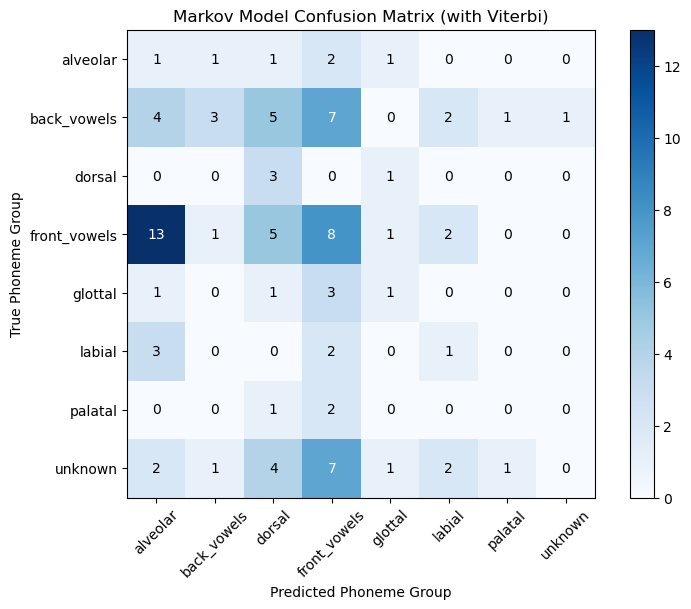

Confusion matrix saved to ./results\markov_model\confusion_matrix.png


In [21]:
# Visualize transition matrix
try:
    markov_model.visualize_transitions()
    print("Transition matrix saved")
except Exception as e:
    print(f"Error visualizing transitions: {e}")

# Plot confusion matrix
if markov_eval_hg is not None:
    import matplotlib.pyplot as plt
    
    conf_matrix = markov_eval_hg['confusion_matrix']
    labels = list(markov_model.group_encoder.classes_)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
    plt.title('Markov Model Confusion Matrix (with Viterbi)')
    plt.colorbar()
    
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)
    
    # Add text annotations
    thresh = conf_matrix.max() / 2.
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            plt.text(j, i, format(conf_matrix[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if conf_matrix[i, j] > thresh else "black")
    
    plt.tight_layout()
    plt.ylabel('True Phoneme Group')
    plt.xlabel('Predicted Phoneme Group')
    
    save_path = os.path.join(markov_model.output_dir, 'confusion_matrix.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Confusion matrix saved to {save_path}")

MarkovPhonemeModel: Transition matrix visualization saved to ./results\markov_model\transition_matrix.png
Transition matrix saved


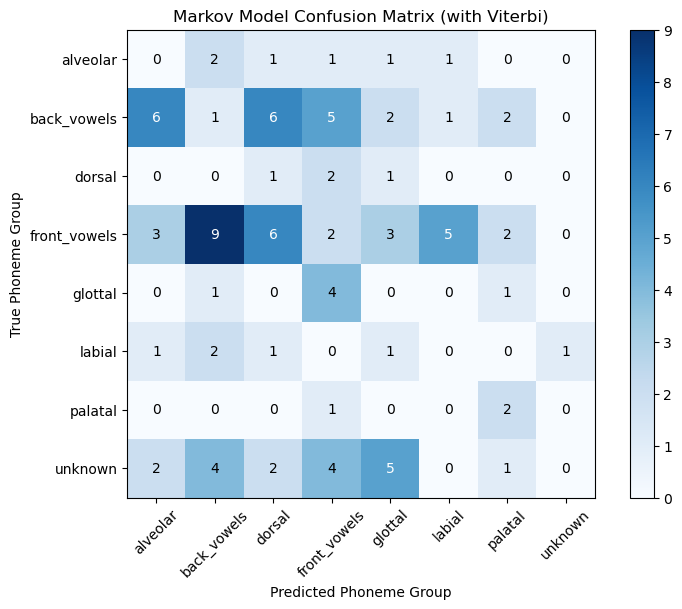

Confusion matrix saved to ./results\markov_model\confusion_matrix.png


In [22]:
# Visualize transition matrix
try:
    markov_model.visualize_transitions()
    print("Transition matrix saved")
except Exception as e:
    print(f"Error visualizing transitions: {e}")

# Plot confusion matrix
if markov_eval_mb is not None:
    import matplotlib.pyplot as plt
    
    conf_matrix = markov_eval_mb['confusion_matrix']
    labels = list(markov_model.group_encoder.classes_)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
    plt.title('Markov Model Confusion Matrix (with Viterbi)')
    plt.colorbar()
    
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)
    
    # Add text annotations
    thresh = conf_matrix.max() / 2.
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            plt.text(j, i, format(conf_matrix[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if conf_matrix[i, j] > thresh else "black")
    
    plt.tight_layout()
    plt.ylabel('True Phoneme Group')
    plt.xlabel('Predicted Phoneme Group')
    
    save_path = os.path.join(markov_model.output_dir, 'confusion_matrix.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Confusion matrix saved to {save_path}")

In [23]:
gmm_model.train(**hg_train_parameters)

gmm_eval_hg = gmm_model.evaluate(**hg_test_parameters)
results['gmm_hmm_hg'] = gmm_eval_hg['accuracy']
print(f"   Accuracy: {gmm_eval_hg['accuracy']:.4f}")

MarkovPhonemeModel: Training Markov chain model...
MarkovPhonemeModel: Mapping phonemes to groups...
MarkovPhonemeModel: Training on 8 classes: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Group distribution: {'alveolar': 43, 'labial': 17, 'front_vowels': 19, 'glottal': 7, 'back_vowels': 27, 'palatal': 12, 'dorsal': 7, 'unknown': 2}
MarkovPhonemeModel: Building transition model...
MarkovPhonemeModel: Built transition model with 26 contexts
MarkovPhonemeModel: Building GMM acoustic model...


C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


MarkovPhonemeModel: Trained GMM for 'alveolar' with 5 components on 43 samples
MarkovPhonemeModel: Trained GMM for 'labial' with 5 components on 17 samples


C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


MarkovPhonemeModel: Trained GMM for 'front_vowels' with 5 components on 19 samples
MarkovPhonemeModel: Trained GMM for 'glottal' with 3 components on 7 samples


C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


MarkovPhonemeModel: Trained GMM for 'back_vowels' with 5 components on 27 samples
MarkovPhonemeModel: Trained GMM for 'palatal' with 5 components on 12 samples


C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


MarkovPhonemeModel: Trained GMM for 'dorsal' with 3 components on 7 samples
MarkovPhonemeModel: Trained GMM for 'unknown' with 1 components on 2 samples
MarkovPhonemeModel: Trained GMM acoustic model on 134 samples
MarkovPhonemeModel: Building initial state probabilities...
MarkovPhonemeModel: Built initial probabilities for 8 states
MarkovPhonemeModel: GMM-HMM model saved to ./results\gmm_hmm\gmm_hmm_model.pkl
MarkovPhonemeModel: First 10 comparisons:
MarkovPhonemeModel:   0: True='alveolar' vs Pred='alveolar' -> True
MarkovPhonemeModel:   1: True='palatal' vs Pred='back_vowels' -> False
MarkovPhonemeModel:   2: True='front_vowels' vs Pred='back_vowels' -> False
MarkovPhonemeModel:   3: True='glottal' vs Pred='alveolar' -> False
MarkovPhonemeModel:   4: True='front_vowels' vs Pred='alveolar' -> False
MarkovPhonemeModel:   5: True='alveolar' vs Pred='back_vowels' -> False
MarkovPhonemeModel:   6: True='alveolar' vs Pred='alveolar' -> True
MarkovPhonemeModel:   7: True='back_vowels' vs 

In [26]:
gmm_model.train(**mb_train_parameters)

gmm_eval_mb = gmm_model.evaluate(**mb_test_parameters)
results['gmm_hmm_mb'] = gmm_eval_mb['accuracy']
print(f"   Accuracy: {gmm_eval_mb['accuracy']:.4f}")

MarkovPhonemeModel: Training Markov chain model...
MarkovPhonemeModel: Mapping phonemes to groups...
MarkovPhonemeModel: Training on 8 classes: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Group distribution: {'alveolar': 43, 'labial': 17, 'front_vowels': 19, 'glottal': 7, 'back_vowels': 27, 'palatal': 12, 'dorsal': 7, 'unknown': 7}
MarkovPhonemeModel: Building transition model...
MarkovPhonemeModel: Built transition model with 30 contexts
MarkovPhonemeModel: Building GMM acoustic model...
MarkovPhonemeModel: Trained GMM for 'alveolar' with 5 components on 43 samples


C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


MarkovPhonemeModel: Trained GMM for 'labial' with 5 components on 17 samples
MarkovPhonemeModel: Trained GMM for 'front_vowels' with 5 components on 19 samples


C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


MarkovPhonemeModel: Trained GMM for 'glottal' with 3 components on 7 samples
MarkovPhonemeModel: Trained GMM for 'back_vowels' with 5 components on 27 samples


C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


MarkovPhonemeModel: Trained GMM for 'palatal' with 5 components on 12 samples
MarkovPhonemeModel: Trained GMM for 'dorsal' with 3 components on 7 samples


C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\irina\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


MarkovPhonemeModel: Trained GMM for 'unknown' with 3 components on 7 samples
MarkovPhonemeModel: Trained GMM acoustic model on 139 samples
MarkovPhonemeModel: Building initial state probabilities...
MarkovPhonemeModel: Built initial probabilities for 8 states
MarkovPhonemeModel: GMM-HMM model saved to ./results\gmm_hmm\gmm_hmm_model.pkl
MarkovPhonemeModel: First 10 comparisons:
MarkovPhonemeModel:   0: True='alveolar' vs Pred='alveolar' -> True
MarkovPhonemeModel:   1: True='palatal' vs Pred='labial' -> False
MarkovPhonemeModel:   2: True='front_vowels' vs Pred='alveolar' -> False
MarkovPhonemeModel:   3: True='glottal' vs Pred='back_vowels' -> False
MarkovPhonemeModel:   4: True='front_vowels' vs Pred='labial' -> False
MarkovPhonemeModel:   5: True='alveolar' vs Pred='front_vowels' -> False
MarkovPhonemeModel:   6: True='alveolar' vs Pred='alveolar' -> True
MarkovPhonemeModel:   7: True='back_vowels' vs Pred='alveolar' -> False
MarkovPhonemeModel:   8: True='alveolar' vs Pred='alveola

MarkovPhonemeModel: Transition matrix visualization saved to ./results\gmm_hmm\transition_matrix.png
Transition matrix saved


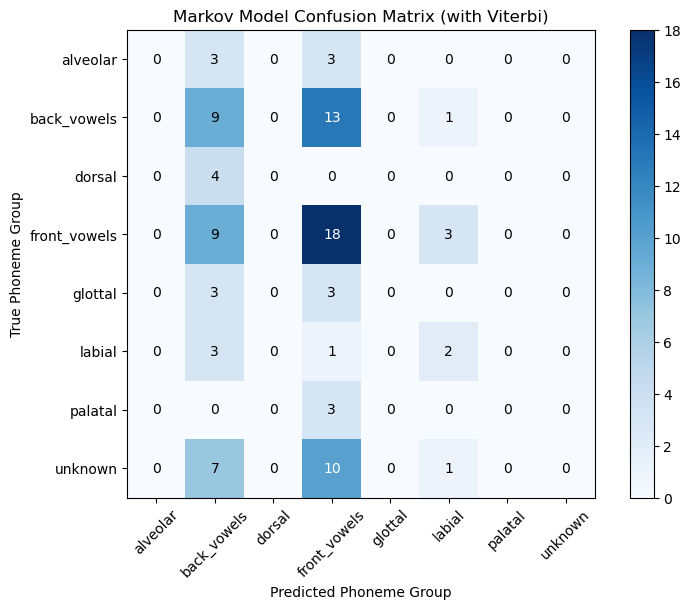

Confusion matrix saved to ./results\markov_model\confusion_matrix.png


In [25]:
# Visualize transition matrix
try:
    gmm_model.visualize_transitions()
    print("Transition matrix saved")
except Exception as e:
    print(f"Error visualizing transitions: {e}")

# Plot confusion matrix
if gmm_eval_hg is not None:
    import matplotlib.pyplot as plt
    
    conf_matrix = gmm_eval_hg['confusion_matrix']
    labels = list(gmm_model.group_encoder.classes_)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
    plt.title('Markov Model Confusion Matrix (with Viterbi)')
    plt.colorbar()
    
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)
    
    # Add text annotations
    thresh = conf_matrix.max() / 2.
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            plt.text(j, i, format(conf_matrix[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if conf_matrix[i, j] > thresh else "black")
    
    plt.tight_layout()
    plt.ylabel('True Phoneme Group')
    plt.xlabel('Predicted Phoneme Group')
    
    save_path = os.path.join(markov_model.output_dir, 'confusion_matrix.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Confusion matrix saved to {save_path}")

MarkovPhonemeModel: Transition matrix visualization saved to ./results\gmm_hmm\transition_matrix.png
Transition matrix saved


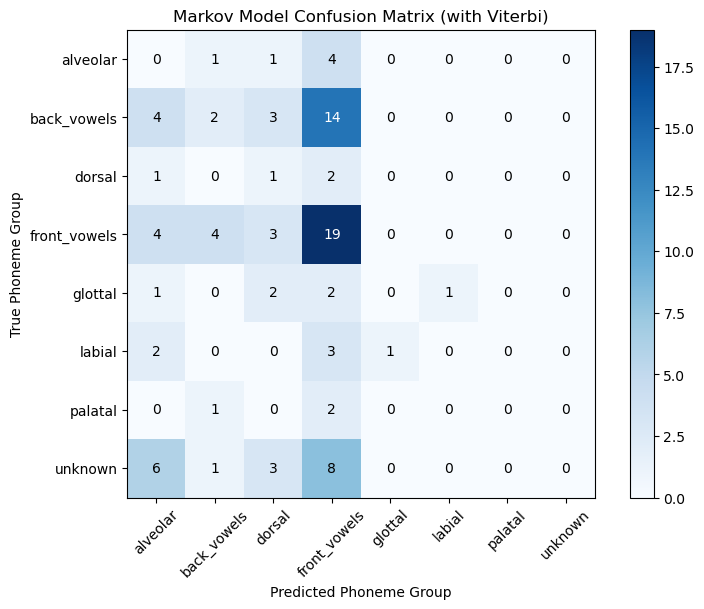

Confusion matrix saved to ./results\markov_model\confusion_matrix.png


In [27]:
# Visualize transition matrix
try:
    gmm_model.visualize_transitions()
    print("Transition matrix saved")
except Exception as e:
    print(f"Error visualizing transitions: {e}")

# Plot confusion matrix
if gmm_eval_mb is not None:
    import matplotlib.pyplot as plt
    
    conf_matrix = gmm_eval_mb['confusion_matrix']
    labels = list(gmm_model.group_encoder.classes_)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
    plt.title('Markov Model Confusion Matrix (with Viterbi)')
    plt.colorbar()
    
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)
    
    # Add text annotations
    thresh = conf_matrix.max() / 2.
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            plt.text(j, i, format(conf_matrix[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if conf_matrix[i, j] > thresh else "black")
    
    plt.tight_layout()
    plt.ylabel('True Phoneme Group')
    plt.xlabel('Predicted Phoneme Group')
    
    save_path = os.path.join(markov_model.output_dir, 'confusion_matrix.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Confusion matrix saved to {save_path}")

In [29]:
hsmm_model.train(**hg_train_parameters)    
hsmm_eval_hg = hsmm_model.evaluate(**hg_test_parameters)
results['hsmm'] = hsmm_eval_hg['accuracy']
print(f"   Accuracy: {hsmm_eval_hg['accuracy']:.4f}")

MarkovPhonemeModel: Training Markov chain model...
MarkovPhonemeModel: Mapping phonemes to groups...
MarkovPhonemeModel: Training on 8 classes: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Group distribution: {'alveolar': 43, 'labial': 17, 'front_vowels': 19, 'glottal': 7, 'back_vowels': 27, 'palatal': 12, 'dorsal': 7, 'unknown': 2}
MarkovPhonemeModel: Building transition model...
MarkovPhonemeModel: Built transition model with 26 contexts
MarkovPhonemeModel: Building acoustic model...
MarkovPhonemeModel: Training on groups: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Trained acoustic model on 134 samples with 8 groups
MarkovPhonemeModel: Building initial state probabilities...
MarkovPhonemeModel: Built initial probabilities for 8 states
MarkovPhonemeModel: HSMM model saved to ./results\hsmm\hsmm_model.pkl
MarkovPhonemeModel: Adding duration m

In [30]:
hsmm_model.train(**mb_train_parameters)    
hsmm_eval_mb = hsmm_model.evaluate(**mb_test_parameters)
results['hsmm'] = hsmm_eval_mb['accuracy']
print(f"   Accuracy: {hsmm_eval_mb['accuracy']:.4f}")

MarkovPhonemeModel: Training Markov chain model...
MarkovPhonemeModel: Mapping phonemes to groups...
MarkovPhonemeModel: Training on 8 classes: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Group distribution: {'alveolar': 43, 'labial': 17, 'front_vowels': 19, 'glottal': 7, 'back_vowels': 27, 'palatal': 12, 'dorsal': 7, 'unknown': 7}
MarkovPhonemeModel: Building transition model...
MarkovPhonemeModel: Built transition model with 30 contexts
MarkovPhonemeModel: Building acoustic model...
MarkovPhonemeModel: Training on groups: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Trained acoustic model on 139 samples with 8 groups
MarkovPhonemeModel: Building initial state probabilities...
MarkovPhonemeModel: Built initial probabilities for 8 states
MarkovPhonemeModel: HSMM model saved to ./results\hsmm\hsmm_model.pkl
MarkovPhonemeModel: Adding duration m

MarkovPhonemeModel: Transition matrix visualization saved to ./results\hsmm\transition_matrix.png
Transition matrix saved


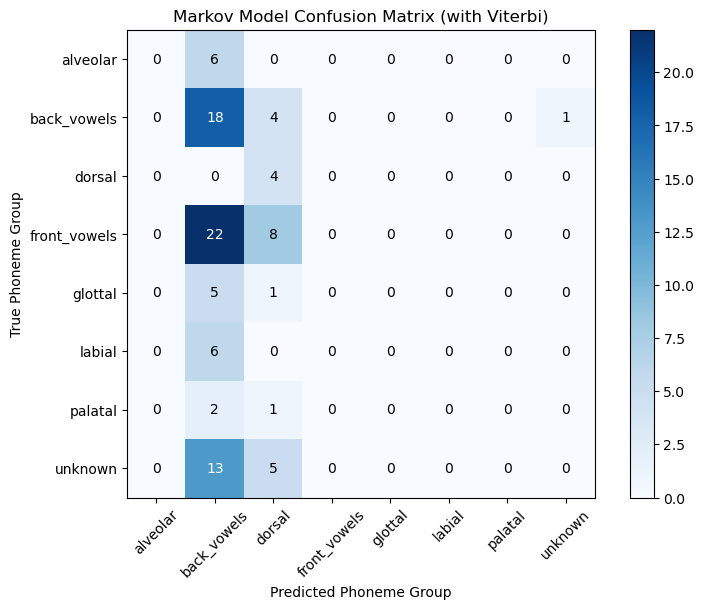

Confusion matrix saved to ./results\markov_model\confusion_matrix.png


In [31]:
# Visualize transition matrix
try:
    hsmm_model.visualize_transitions()
    print("Transition matrix saved")
except Exception as e:
    print(f"Error visualizing transitions: {e}")

# Plot confusion matrix
if hsmm_eval_hg is not None:
    import matplotlib.pyplot as plt
    
    conf_matrix = hsmm_eval_hg['confusion_matrix']
    labels = list(hsmm_model.group_encoder.classes_)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
    plt.title('Markov Model Confusion Matrix (with Viterbi)')
    plt.colorbar()
    
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)
    
    # Add text annotations
    thresh = conf_matrix.max() / 2.
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            plt.text(j, i, format(conf_matrix[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if conf_matrix[i, j] > thresh else "black")
    
    plt.tight_layout()
    plt.ylabel('True Phoneme Group')
    plt.xlabel('Predicted Phoneme Group')
    
    save_path = os.path.join(markov_model.output_dir, 'confusion_matrix.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Confusion matrix saved to {save_path}")

MarkovPhonemeModel: Transition matrix visualization saved to ./results\hsmm\transition_matrix.png
Transition matrix saved


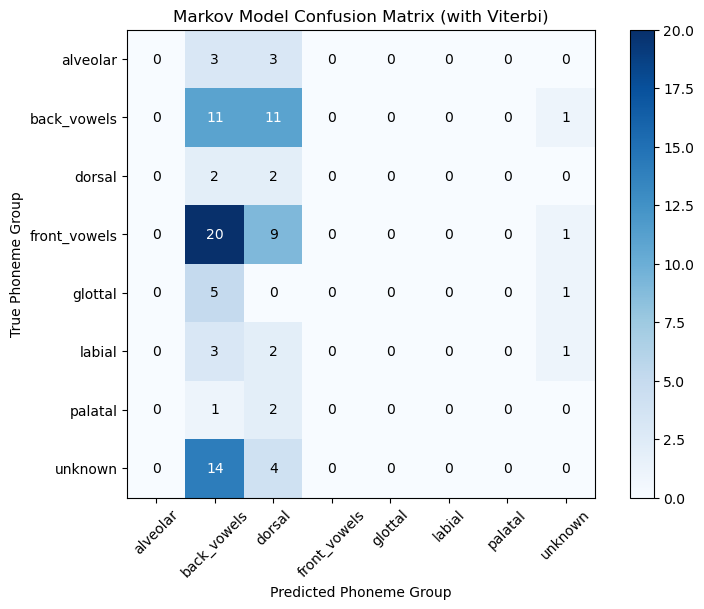

Confusion matrix saved to ./results\markov_model\confusion_matrix.png


In [32]:
# Visualize transition matrix
try:
    hsmm_model.visualize_transitions()
    print("Transition matrix saved")
except Exception as e:
    print(f"Error visualizing transitions: {e}")

# Plot confusion matrix
if hsmm_eval_mb is not None:
    import matplotlib.pyplot as plt
    
    conf_matrix = hsmm_eval_mb['confusion_matrix']
    labels = list(hsmm_model.group_encoder.classes_)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
    plt.title('Markov Model Confusion Matrix (with Viterbi)')
    plt.colorbar()
    
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)
    
    # Add text annotations
    thresh = conf_matrix.max() / 2.
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            plt.text(j, i, format(conf_matrix[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if conf_matrix[i, j] > thresh else "black")
    
    plt.tight_layout()
    plt.ylabel('True Phoneme Group')
    plt.xlabel('Predicted Phoneme Group')
    
    save_path = os.path.join(markov_model.output_dir, 'confusion_matrix.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Confusion matrix saved to {save_path}")